In [13]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)

In [2]:
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"             "Bulk"

In [24]:
diseases= c('Fibrosis.stage', 'MASH_ALL_vs_Control', 'MASH_vs_Control', 'MASL_vs_Control', 'MetALD_vs_Control','fibrosis')
modalities <- c('H3K27ac','H3K27me3','ATAC',
                'H3K27ac_ATAC_Peaks','H3K27ac_TSS','H3K27me3_ATAC_Peaks','H3K27me3_TSS')
sig_level <- c('nominal','padj')
direction <- c('up','down')
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)


In [3]:
celltypes <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')
subtypes <- c('Activated.HSC','B','Central.Vein.Endothelial','Cholangiocyte',
              'Hepatocytes.Senescent','Hepatocytes.Stress','Hepatocytes.Zone1',
              'Hepatocytes.Zone2','Hepatocytes.Zone3','Kupffer','Lipid.Associated.Macrophage',
             'Lymphatic.Endothelial','Macrophage','Mast','Mesenchymal','NK','Plasma',
             'Quescent.HSC','Schwann','Sinusoidal.Endothelial','T','Vascular.Endothelial')
Hepato_subtypes <- c('Hepatocytes.Senescent','Hepatocytes.Stress','Hepatocytes.Zone1',
              'Hepatocytes.Zone2','Hepatocytes.Zone3')
Endo_subtypes <- c('Central.Vein.Endothelial','Sinusoidal.Endothelial','Vascular.Endothelial','Lymphatic.Endothelial')
HSC_subtypes <- c('Activated.HSC','Quescent.HSC','Mesenchymal')
Myeloid_subtypes <- c('Kupffer','Lipid.Associated.Macrophage','Macrophage')

In [4]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [5]:
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
#background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

In [6]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [9]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [31]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [36]:
Sys.time()
commands <- character()

for(FILE in trait_beds[1]){
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)

    for(MOD in modalities){
        message(MOD)

        for(DIRECT in direction){
            message(DIRECT)
            for(SIG in sig_level){
                message(SIG)
                for (CELL in cells){
                    #message(CELL)
                    for (disease_num in 1:length(diseases)){
                        input_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/%s.%s_%s.dds.res.%s.%s.bed', MOD, CELL,diseases[disease_num],SIG, DIRECT))
                        if (file.exists(str_replace(input_name, '/tscc/projects/ps-gaultonlab','/nfs/lab/tscc'))) {
                            
                            if(MOD %in% c('H3K27ac','H3K27me3','H3K27ac_ATAC_Peaks','H3K27me3_ATAC_Peaks','H3K27ac_TSS','H3K27me3_TSS')){
                                background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s.%s_background.bed', MOD, CELL))
    
                            }else if (MOD %in% c('ATAC')) {
                               background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s_union.peaks', CELL))
    
                            }
                            
                            cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
                            commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                                           out.dir,CELL,'_',MOD,'_',DIRECT,'_',SIG,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                                           ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
                        }
                    }
                }
            }
        }
    }
    
    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    #Cell type specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed'
    for (CELL in celltypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Sub type specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/subtype_union_peaks.bed'
    for (CELL in subtypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_subtype_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Hepatocytes subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Hepatocyte_only_union_peaks.bed'
    for (CELL in Hepato_subtypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_Hepatocytes_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Endothelial subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Endothelial_only_union_peaks.bed'
    for (CELL in Endo_subtypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_Endothelial_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #HSC subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/HSC_only_union_peaks.bed'
    for (CELL in HSC_subtypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_HSC_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Myeloid subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Myeloid_only_union_peaks.bed'
    for (CELL in Myeloid_subtypes){
        input_name <- paste0(bed.dir.tscc, CELL, "_Myeloid_specific_5k.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    for (CELL in c('Hepatocytes','Myeloid','HSC','Endothelial')) {
        background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241217_WE_',CELL,'_disease_differential_background_clusters.bed')
        clusters <- c('_disease_differential_MASH_clusters.bed', '_disease_differential_MASH_on_clusters.bed', 
                      '_disease_differential_MASH_specific_cluste', '_disease_differential_MASL_clusters.bed', 
                      '_disease_differential_MASL_on_clusters.bed', '_disease_differential_MASL_specific_cluste', 
                      '_disease_differential_MetALD_clusters.bed')
        input_name <- paste0(bed.dir.tscc,'241217_WE_', CELL, clusters)
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        
        background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241217_WE_',CELL,'_disease_background_clusters.bed')
        clusters <- c('_disease_MASH_clusters.bed', '_disease_MASH_on_clusters.bed', 
                      '_disease_MASH_specific_clusters', '_disease_MASL_clusters.bed', 
                      '_disease_MASL_on_clusters.bed', '_disease_MASL_specific_clusters', 
                      '_disease_MetALD_clusters.bed')
        input_name <- paste0(bed.dir.tscc,'241217_WE_', CELL, clusters)
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
}

Sys.time()

length(commands)
head(commands)

commands[str_detect(commands, 'nfs')]

[1] "2024-12-17 15:37:39 PST"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed

H3K27ac

up

nominal

padj

down

nominal

padj

H3K27me3

up

nominal

padj

down

nominal

padj

ATAC

up

nominal

padj

down

nominal

padj

H3K27ac_ATAC_Peaks

up

nominal

padj

down

nominal

padj

H3K27ac_TSS

up

nominal

padj

down

nominal

padj

H3K27me3_ATAC_Peaks

up

nominal

padj

down

nominal

padj

H3K27me3_TSS

up

nominal

padj

down

nominal

padj

HMM_Active

up

nominal

padj

down

nominal

padj

HMM_Inactive

up

nominal

padj

down

nominal

padj



[1] "2024-12-17 15:38:17 PST"

[1] 856

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_Fibrosis.stage.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.B_Fibrosis.stage.dds.res.nominal.up.bed.results "                                                
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed.results "                                      
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASH_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.B_MASH_vs_Control.dds.res.nominal.up.bed.results "                                              
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASL_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.B_MASL_vs_Control.dds.res.nominal.up.bed.results "                                              
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MetALD_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.B_MetALD_vs_Control.dds.res.nominal.up.bed.results "                                          
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.Cholangiocyte_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte_H3K27ac_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27ac.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed.results "

character(0)

In [37]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/241217_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [60]:
Sys.time()
commands <- character()

for(FILE in trait_beds[1]){
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)
    
    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    #Cell type specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed'
    for (CELL in celltypes){
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Sub type specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/subtype_union_peaks.bed'
    for (CELL in subtypes){
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_subtypes.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_subtypes.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #Hepatocytes subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Hepatocyte_only_union_peaks.bed'
    for (CELL in Hepato_subtypes){
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_Hepatocytes.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_Hepatocytes.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    #HSC subtypes specific peaks
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/HSC_only_union_peaks.bed'
    for (CELL in HSC_subtypes){
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_HSC.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        
        input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_HSC.bed")
        
        cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed', CELL))
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
}

Sys.time()

length(commands)
head(commands)

commands[str_detect(commands, 'nfs')]

[1] "2024-12-18 12:33:39 PST"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed



[1] "2024-12-18 12:33:39 PST"

[1] 80

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_B_Yang_marker_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_marker_peaks.bed.results "                                        
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_B_Yang_specific_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_specific_peaks.bed.results "                                    
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Cholangiocyte_Yang_marker_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Cholangiocyte_Yang_marker_peaks.bed.results "    
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Cholangiocyte_Yang_specific_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Cholangiocyte_Yang_specific_peaks.bed.results "
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Endothelial_Yang_marker_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Endothelial_Yang_marker_peaks.bed.results "          
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Endothelial_Yang_specific_peaks.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Endothelial_Yang_specific_peaks.bed.results "

character(0)

In [61]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/241218_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [43]:
out.dir.ophelia <- paste0(str_replace(out.dir, '/tscc/projects/ps-gaultonlab', '/nfs/lab/tscc'),'MVP.NAFLD.TRANS/')
out.dir.ophelia

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/MVP.NAFLD.TRANS/"

In [124]:
files <- list.files(out.dir.ophelia)

length(files)
head(files)
tail(files)

[1] 936

[1] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_HSC.bed.results"       
[2] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_subtypes.bed.results"  
[3] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_HSC.bed.results"     
[4] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_subtypes.bed.results"
[5] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_HSC_specific_5k.bed.results"                       
[6] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_subtype_specific_5k.bed.results"

[1] "T_H3K27me3_TSS_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_TSS.T_MetALD_vs_Control.dds.res.padj.up.bed.results"         
[2] "T_H3K27me3_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3.T_Fibrosis.stage.dds.res.nominal.up.bed.results"              
[3] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Vascular.Endothelial_Yang_marker_peaks_subtypes.bed.results"  
[4] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Vascular.Endothelial_Yang_specific_peaks_subtypes.bed.results"
[5] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Vascular.Endothelial_Endothelial_specific_5k.bed.results"               
[6] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Vascular.Endothelial_subtype_specific_5k.bed.results"

In [87]:
out.df <- data.frame()

for (file in files[grep('Yang', files)]) {
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(file, '__', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- ifelse(str_detect(in.file, 'specific'), 
                        ifelse(str_detect(in.file, 'HSC.bed'),'HSC.specific',
                        ifelse(str_detect(in.file, 'Hepatocytes.bed'),'Hepatocytes.specific',
                        ifelse(str_detect(in.file, 'subtype'),'Subtype.specific','Celltype.specific'))),
                        ifelse(str_detect(in.file, 'HSC.bed'),'HSC.marker',
                        ifelse(str_detect(in.file, 'Hepatocytes.bed'),'Hepatocytes.marker',
                        ifelse(str_detect(in.file, 'subtype'),'Subtype.marker','Celltype.marker'))))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- NA
        results$modality <- 'ATAC'
        results$DESeq_direction <- NA
        results$Sig_level <- NA
        results$cell_type <- ct
        results$unit <- test.group
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.marker,NA,ATAC,NA,NA,Activated.HSC,HSC.marker,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.marker,NA,ATAC,NA,NA,Activated.HSC,Subtype.marker,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.specific,NA,ATAC,NA,NA,Activated.HSC,HSC.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.specific,NA,ATAC,NA,NA,Activated.HSC,Subtype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.marker,NA,ATAC,NA,NA,B,Subtype.marker,0.039,8.60757384977595,2.205461481909571,0.1203834142997878,20.187222800092716
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.marker,NA,ATAC,NA,NA,B,Celltype.marker,0.06,3.9872478514827665,1.44113170824853,-0.26776129092683587,8.597192916235201
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.specific,NA,ATAC,NA,NA,B,Subtype.specific,0.033,16.966637552182554,2.873701429392299,0.4475287331905816,60.258573509225535
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.specific,NA,ATAC,NA,NA,B,Celltype.specific,0.235,0.5245603201634149,-0.6481120086136896,-2.8180675295470228,21.646875392698096
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Subtype.marker,NA,ATAC,NA,NA,Central.Vein.Endothelial,Subtype.marker,1.0,0.0,-Infinity,-Infinity,-Infinity


In [92]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_new_ATAC_markers_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
new.marker.df <- out.df

In [296]:
new.marker.df %>%
    select(trait, Cell.Type=ct, Comparison.Group=test.group, modality, pval, fold_enrich, logOR, conf_lower, conf_upper) %>%
    filter(str_detect(Comparison.Group,'specific')) %>%
    group_by(Comparison.Group) %>%
    mutate(pval=as.numeric(pval)) %>%
    mutate(qval=qvalue(pval)$qvalues) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_new_ATAC_markers_FINRICH_results.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)

In [171]:
files[grep('5k', files)]

[1] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_HSC_specific_5k.bed.results"                                
 [2] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_subtype_specific_5k.bed.results"                            
 [3] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__B_specific_5k.bed.results"                                                            
 [4] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__B_subtype_specific_5k.bed.results"                                                    
 [5] "Central.Vein.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Central.Vein.Endothelial_Endothelial_specific_5k.bed.results"  
 [6] "Central.Vein.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Central.Vein.Endothelial_subtype_specific_5k.bed.results"      
 [7] "Cholangiocyte__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Cholangiocyte_specific_5k.bed.results"                                    
 [8] "Cholangiocyte__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Cholangiocyte_subtype_specific_5k.bed.results"                            
 [9] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Endothelial_specific_5k.bed.results"                                        
[10] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes_specific_5k.bed.results"                                        
[11] "Hepatocytes.Senescent__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Senescent_Hepatocytes_specific_5k.bed.results"        
[12] "Hepatocytes.Senescent__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Senescent_subtype_specific_5k.bed.results"            
[13] "Hepatocytes.Stress__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Stress_Hepatocytes_specific_5k.bed.results"              
[14] "Hepatocytes.Stress__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Stress_subtype_specific_5k.bed.results"                  
[15] "Hepatocytes.Zone1__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone1_Hepatocytes_specific_5k.bed.results"                
[16] "Hepatocytes.Zone1__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone1_subtype_specific_5k.bed.results"                    
[17] "Hepatocytes.Zone2__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone2_Hepatocytes_specific_5k.bed.results"                
[18] "Hepatocytes.Zone2__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone2_subtype_specific_5k.bed.results"                    
[19] "Hepatocytes.Zone3__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone3_Hepatocytes_specific_5k.bed.results"                
[20] "Hepatocytes.Zone3__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Hepatocytes.Zone3_subtype_specific_5k.bed.results"                    
[21] "HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__HSC_specific_5k.bed.results"                                                        
[22] "Kupffer__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Kupffer_Myeloid_specific_5k.bed.results"                                        
[23] "Kupffer__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Kupffer_subtype_specific_5k.bed.results"                                        
[24] "Lipid.Associated.Macrophage__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Lipid.Associated.Macrophage_Myeloid_specific_5k.bed.results"
[25] "Lipid.Associated.Macrophage__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Lipid.Associated.Macrophage_subtype_specific_5k.bed.results"
[26] "Lymphatic.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Lymphatic.Endothelial_Endothelial_specific_5k.bed.results"        
[27] "Lymphatic.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Lymphatic.Endothelial_subtype_specific_5k.bed.results"            
[28] "Macrophage__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Macrophage_Myeloid_specific_5k.bed.results"                                  
[29] "Macrophage__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Macrophage_subtype_specific_5k.bed.results"                                  
[30] "Mast__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Mast_specific_5k.bed.results"                                    

In [173]:
length(files[grep('5k', files)])

[1] 47

In [186]:
out.df <- data.frame()

for (file in files[grep('5k', files)]) {
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(file, '__', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- ifelse(str_detect(in.file, 'specific'), 
                        ifelse(str_detect(in.file, 'subtype'),'Subtype.specific',
                        ifelse(str_detect(in.file, 'Hepatocytes.[Z|S]'),'Hepatocytes.specific',
                        ifelse(str_detect(in.file, '([Lipid.Associated.Macrophage]|[Macrophage]|[Kupffer])_Mye'),'Myeloid.specific',
                        ifelse(str_detect(in.file, '([Lymphatic.Endothelial]|[Central.Vein.Endothelial]|[Sinusoidal.Endothelial]|[Vascular.Endothelial])_Endo'),'Endothelial.specific',
                        ifelse(str_detect(in.file, '([Activated.HSC]|[Quescent.HSC]|[Mesenchymal])_HSC'),'HSC.specific','Celltype.specific'))))))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- NA
        results$modality <- 'ATAC'
        results$DESeq_direction <- NA
        results$Sig_level <- NA
        results$cell_type <- ct
        results$unit <- test.group
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.specific,NA,ATAC,NA,NA,Activated.HSC,HSC.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.specific,NA,ATAC,NA,NA,Activated.HSC,Subtype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.specific,NA,ATAC,NA,NA,B,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.specific,NA,ATAC,NA,NA,B,Subtype.specific,0.661,0.022990929681845174,-3.780019157389389,-5.788246792615643,11.135512654594622
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Endothelial.specific,NA,ATAC,NA,NA,Central.Vein.Endothelial,Endothelial.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Subtype.specific,NA,ATAC,NA,NA,Central.Vein.Endothelial,Subtype.specific,0.572,0.01964257447135477,-3.935119489578739,-6.119746214082601,19.644056113662923
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,Celltype.specific,NA,ATAC,NA,NA,Cholangiocyte,Celltype.specific,0.5,0.15174669517965078,-1.8922841851860137,-3.9087825636553113,13.211786436615007
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,Subtype.specific,NA,ATAC,NA,NA,Cholangiocyte,Subtype.specific,0.469,0.13958122144037352,-1.9750021539178046,-4.030719644217636,14.799226999019385
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,Celltype.specific,NA,ATAC,NA,NA,Endothelial,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity


In [187]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_5k_ATAC_markers_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
old.marker.df <- out.df

In [287]:
old.marker.df %>%
    select(trait, Cell.Type=ct, Comparison.Group=test.group, modality, pval, fold_enrich, logOR, conf_lower, conf_upper) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_5k_ATAC_markers_FINRICH_results.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)

In [210]:
out.df <- data.frame()

for (file in files[grep('dds', files)]) {
    test.group <- 'DESeq'
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(str_split(file, '__', simplify=T)[1], '_', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    disease_condition <- ifelse(str_detect(in.file, 'Fibrosis.stage'), 'Fibrosis.stage',
                         ifelse(str_detect(in.file, 'MASH_vs_Control'), 'MASH_vs_Control',
                         ifelse(str_detect(in.file, 'MetALD_vs_Control'), 'MetALD_vs_Control',
                         ifelse(str_detect(in.file, 'MASH_ALL_vs_Control'), 'MASH_ALL_vs_Control','MASL_vs_Control'))))
            
    direction <- ifelse(str_detect(in.file, 'down'), 'down', 'up')
    Sig_level <- ifelse(str_detect(in.file, 'nominal'), 'nominal', 'padj')
    modality <- str_split(file, '__', simplify=T)[1] %>%
                    str_remove(paste0(ct,'_')) %>%
                    str_remove(paste0('_',Sig_level)) %>%
                    str_remove(paste0('_',direction))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- disease_condition
        results$modality <- modality
        results$DESeq_direction <- direction
        results$Sig_level <- Sig_level
        results$cell_type <- ct
        results$unit <- test.group
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,up,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,ATAC,up,nominal,B,DESeq,0.518,0.09671634202214528,-2.357939419834207,-4.635391654417048,17.931063345714435


In [211]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_5k_DESeq_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
de.df <- out.df

In [297]:
de.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,up,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,ATAC,up,nominal,B,DESeq,0.518,0.09671634202214528,-2.357939419834207,-4.635391654417048,17.931063345714435


In [306]:
de.df %>%
    filter(modality=='ATAC') %>%
    select(trait, Cell.Type=ct, disease.condition=disease_condition, modality, DESeq_direction, Sig_level,
           pval, fold_enrich, logOR, conf_lower, conf_upper) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_DESeq_ATAC_FINRICH_results.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)

In [ ]:
%>%
    mutate(qval=ifelse(n>2,qvalue(pval)$qvalues, NA))

In [307]:
files

[1] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_HSC.bed.results"                                                              
  [2] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_subtypes.bed.results"                                                         
  [3] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_HSC.bed.results"                                                            
  [4] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_subtypes.bed.results"                                                       
  [5] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_HSC_specific_5k.bed.results"                                                                              
  [6] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_subtype_specific_5k.bed.results"                                                                          
  [7] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_marker_peaks_subtypes.bed.results"                                                                                 
  [8] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_marker_peaks.bed.results"                                                                                          
  [9] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_specific_peaks_subtypes.bed.results"                                                                               
 [10] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_B_Yang_specific_peaks.bed.results"                                                                                        
 [11] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__B_specific_5k.bed.results"                                                                                                          
 [12] "B__MVP.NAFLD.TRANS.MVP.2021.credset.bed__B_subtype_specific_5k.bed.results"                                                                                                  
 [13] "B_ATAC_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_Fibrosis.stage.dds.res.nominal.down.bed.results"                                                           
 [14] "B_ATAC_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MASH_ALL_vs_Control.dds.res.nominal.down.bed.results"                                                      
 [15] "B_ATAC_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MASH_vs_Control.dds.res.nominal.down.bed.results"                                                          
 [16] "B_ATAC_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MASL_vs_Control.dds.res.nominal.down.bed.results"                                                          
 [17] "B_ATAC_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MetALD_vs_Control.dds.res.nominal.down.bed.results"                                                        
 [18] "B_ATAC_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_Fibrosis.stage.dds.res.padj.down.bed.results"                                                                 
 [19] "B_ATAC_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MetALD_vs_Control.dds.res.padj.down.bed.results"                                                              
 [20] "B_ATAC_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_Fibrosis.stage.dds.res.nominal.up.bed.results"                                                               
 [21] "B_ATAC_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed.results"                                                          
 [22] "B_ATAC_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__ATAC.B_MASH_vs_Control.dds.res.nominal.up.bed.results"                                                              
 [23] "B_ATAC_up_nom

In [308]:
files[grep('clust', files)]

[1] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_clusters.bed.results"         
 [2] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_on_clusters.bed.results"      
 [3] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_specific_clusters.bed.results"
 [4] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_clusters.bed.results"         
 [5] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_on_clusters.bed.results"      
 [6] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_specific_cluste.results"      
 [7] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MetALD_clusters.bed.results"       
 [8] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_clusters.bed.results"                      
 [9] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_on_clusters.bed.results"                   
[10] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_specific_cluste.results"                   
[11] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_clusters.bed.results"                      
[12] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_on_clusters.bed.results"                   
[13] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_specific_cluste.results"                   
[14] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MetALD_clusters.bed.results"                    
[15] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_clusters.bed.results"         
[16] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_on_clusters.bed.results"      
[17] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_specific_cluste.results"      
[18] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_clusters.bed.results"         
[19] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_on_clusters.bed.results"      
[20] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_specific_cluste.results"      
[21] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MetALD_clusters.bed.results"       
[22] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_clusters.bed.results"                      
[23] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_on_clusters.bed.results"                   
[24] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_specific_cluste.results"                   
[25] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_clusters.bed.results"                      
[26] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_on_clusters.bed.results"                   
[27] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_specific_cluste.results"                   
[28] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MetALD_clusters.bed.results"                    
[29] "HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_HSC_disease_differential_MASH_clusters.bed.results"                         
[30] "HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_W

In [312]:
out.df <- data.frame()

for (file in files[grep('clust', files)]) {
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(file, '__', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- ifelse(str_detect(in.file,'differential'),'differential','all')
    
    unit <- ifelse(str_detect(in.file, 'MASH'), 
                        ifelse(str_detect(in.file, 'on_clusters'),'MASH_on',
                        ifelse(str_detect(in.file, 'specific'),'MASH_specific','MASH')),
                  ifelse(str_detect(in.file, 'MASL'), 
                        ifelse(str_detect(in.file, 'on_clusters'),'MASL_on',
                        ifelse(str_detect(in.file, 'specific'),'MASL_specific','MASL')),'MetALD'))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- NA
        results$modality <- 'ATAC'
        results$DESeq_direction <- NA
        results$Sig_level <- NA
        results$cell_type <- ct
        results$unit <- unit
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

#Endo differential - no loci in background

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH_on,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH_specific,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL_on,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL_specific,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MetALD,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,all,NA,ATAC,NA,NA,Endothelial,MASH,0.669,0.32691240301857755,-1.1441480641275419,-2.558299961501757,2.55230930996402
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,all,NA,ATAC,NA,NA,Endothelial,MASH_on,0.229,0.9857902285901523,-0.014445641990136648,-1.9873851870792056,13.445444301295307


In [313]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_cluster_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
cluster.df <- out.df

In [316]:
cluster.df.filt <- cluster.df %>%
    filter(test.group=='all') %>%
    select(trait, Cell.Type=ct,unit, pval, fold_enrich, logOR, conf_lower, conf_upper)

In [317]:
filter(cluster.df.filt, as.numeric(pval)< 0.05)

trait,Cell.Type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MetALD,0.0,3.025405395769916,1.6098086234971505,0.6416336920858707,2.8972432073622794
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MASL,0.004,3.065397348711432,1.363513853141449,0.28222975517362414,3.1331389988091543
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MASL_specific,0.001,3.4438887063241452,1.485614703201666,0.3566489360843019,3.4519058878748408
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASH_specific,0.042,3.219428037191505,1.2413636491740803,-0.2589275238307973,5.71629729446062


In [341]:
pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241220_WE_state_FINRICH_barplot.pdf')

cluster.df.filt %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=unit, fill=unit)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = .2, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=c(MASL="#1b9e77", MASL_specific="#2ec496", MASL_on="#48e1b5", 
                               MASH="#7570b3", MASH_specific="#9489c9", MASH_on="#b2a3df", MetALD="#e7298a")) + 
    theme(legend.position='None') + facet_wrap(. ~ Cell.Type)

dev.off()

pdf 
  2

In [343]:
dev.off()

null device 
          1

In [338]:
cluster.df.filt %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) 

trait,Cell.Type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj,ct,lab
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<fct>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH_specific,0.821,0.04501264,-3.118422086388626,-4.830193110090128,4.093434473864024,0.91434855,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH,0.988,0.06708925,-2.7743339745389908,-3.9275400042807833,-0.6830481855681412,0.98572207,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH_on,0.962,0.07342055,-2.666097701405461,-3.9456068695940925,0.045959052759172,0.98572207,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH_specific,0.829,0.10832478,-2.248932856487847,-3.780621232521281,2.5234034561880003,0.91434855,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MASH_on,0.746,0.17650293,-1.761382323098668,-3.1952721746574633,2.1813210922190924,0.90608003,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MetALD,0.851,0.19926529,-1.6587037289706252,-2.907850190135222,0.945294137639366,0.91434855,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASH_on,0.663,0.19957365,-1.6344633485200357,-3.180470294479959,3.290727123468054,0.89792496,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH,0.669,0.32691240,-1.1441480641275419,-2.558299961501757,2.55230930996402,0.89792496,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MetALD,0.675,0.37982105,-0.9984437562554811,-2.3081840825281974,1.966511072147459,0.89792496,Myeloid,


In [327]:
cluster.df.filt.diff <- cluster.df %>%
    filter(test.group=='differential') %>%
    select(trait, Cell.Type=ct,unit, pval, fold_enrich, logOR, conf_lower, conf_upper)

In [340]:
pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241220_WE_state_differential_FINRICH_barplot.pdf')

cluster.df.filt.diff %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=unit, fill=unit)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = .2, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=c(MASL="#1b9e77", MASL_specific="#2ec496", MASL_on="#48e1b5", 
                               MASH="#7570b3", MASH_specific="#9489c9", MASH_on="#b2a3df", MetALD="#e7298a")) + 
    theme(legend.position='None') + facet_wrap(. ~ Cell.Type)

dev.off()

Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_col()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_text()`).”


pdf 
  2

In [4]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
read.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_cluster_FINRICH.tsv', header=T) %>%
    filter(test.group=='all') %>%
    select(trait, Cell.Type=ct,unit, pval, fold_enrich, logOR, conf_lower, conf_upper) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/res')

trait,Cell.Type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH,0.669,0.32691240,-1.14414806,-2.5583000,2.55230931
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH_on,0.229,0.98579023,-0.01444564,-1.9873852,13.44544430
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH_specific,0.829,0.10832478,-2.24893286,-3.7806212,2.52340346
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASL,0.442,1.03978418,0.04691367,-0.9056487,1.30257885
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASL_on,0.439,1.01288568,0.01442463,-1.0387123,1.63947379
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASL_specific,0.386,1.18117564,0.17601125,-1.1675335,3.27896501
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MetALD,0.000,3.02540540,1.60980862,0.6416337,2.89724321
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH,0.988,0.06708925,-2.77433397,-3.9275400,-0.68304819
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH_on,0.962,0.07342055,-2.66609770,-3.9456069,0.04595905


In [ ]:
old.marker.df
de.df

In [126]:
new.marker.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.marker,NA,ATAC,NA,NA,Activated.HSC,HSC.marker,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.marker,NA,ATAC,NA,NA,Activated.HSC,Subtype.marker,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.specific,NA,ATAC,NA,NA,Activated.HSC,HSC.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.specific,NA,ATAC,NA,NA,Activated.HSC,Subtype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.marker,NA,ATAC,NA,NA,B,Subtype.marker,0.039,8.60757384977595,2.205461481909571,0.1203834142997878,20.187222800092716
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.marker,NA,ATAC,NA,NA,B,Celltype.marker,0.06,3.9872478514827665,1.44113170824853,-0.26776129092683587,8.597192916235201
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.specific,NA,ATAC,NA,NA,B,Subtype.specific,0.033,16.966637552182554,2.873701429392299,0.4475287331905816,60.258573509225535
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.specific,NA,ATAC,NA,NA,B,Celltype.specific,0.235,0.5245603201634149,-0.6481120086136896,-2.8180675295470228,21.646875392698096
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Subtype.marker,NA,ATAC,NA,NA,Central.Vein.Endothelial,Subtype.marker,1.0,0.0,-Infinity,-Infinity,-Infinity


In [235]:
library(qvalue)

Warning message:
“package ‘qvalue’ was built under R version 4.4.2”


In [141]:
# Cell type colors (middle brightness)
celltype_colors <- c(
  NK = "#6A0DAD",          # Medium Purple
  T = "#9B59B6",           # Light Purple
  Endothelial = "#E41A1C", # Medium Red
  Myeloid = "#FF7F00",     # Medium Orange
  B = "#8A2BE2",           # Medium Purple
  Cholangiocyte = "#FFD92F",# Choral
  HSC = "#1E90FF",         # Blue
  Mast = "#8B4513",        # Medium Yellow
  Schwann = "#808080",     # Grey
  Hepatocytes = "#4DAF4A"  # Medium Green
)

# Cell subtype colors (distinct shades)
cellsubtype_colors <- c(
  NK = "#6A0DAD",                                      # Medium Purple
  T = "#9B59B6",                                       # Light Purple
  Sinusoidal.Endothelial = "#D3372E",                  # Dark Red
  Lymphatic.Endothelial = "#FFCCBC",                   # Light Red
  Central.Vein.Endothelial = "#E46F69",                # Light Red
  Vascular.Endothelial = "#B22222",                    # Pale Red 
  Kupffer = "#CC4C02",                                 # Dark Orange
  Macrophage = "#FF7F00",                              # Orange
  Lipid.Associated.Macrophage = "#FC8D59",             # Light Orange
  B = "#8A2BE2",                                       # Medium Purple
  Plasma = "#BA55D3",                                  # Distinct Purple
  Cholangiocyte = "#FFD92F",                           # Choral
  Quescent.HSC = "#4682B4",                            # Steel Blue
  Activated.HSC = "#1E90FF",                           # Blue
  Mesenchymal = "#000080",                             # Navy
  Mast = "#8B4513",                                    # Medium Yellow
  Schwann = "#808080",                                 # Grey
  Hepatocytes.Zone1 = "#006D2C",                       # Dark Green
  Hepatocytes.Zone2 = "#4DAF4A",                       # Green
  Hepatocytes.Zone3 = "#78C679",                       # Light Green
  Hepatocytes.Senescent = "#A6D96A",                   # Pale Green
  Hepatocytes.Stress = "#D9F0A3"                       # Very Pale Green
)


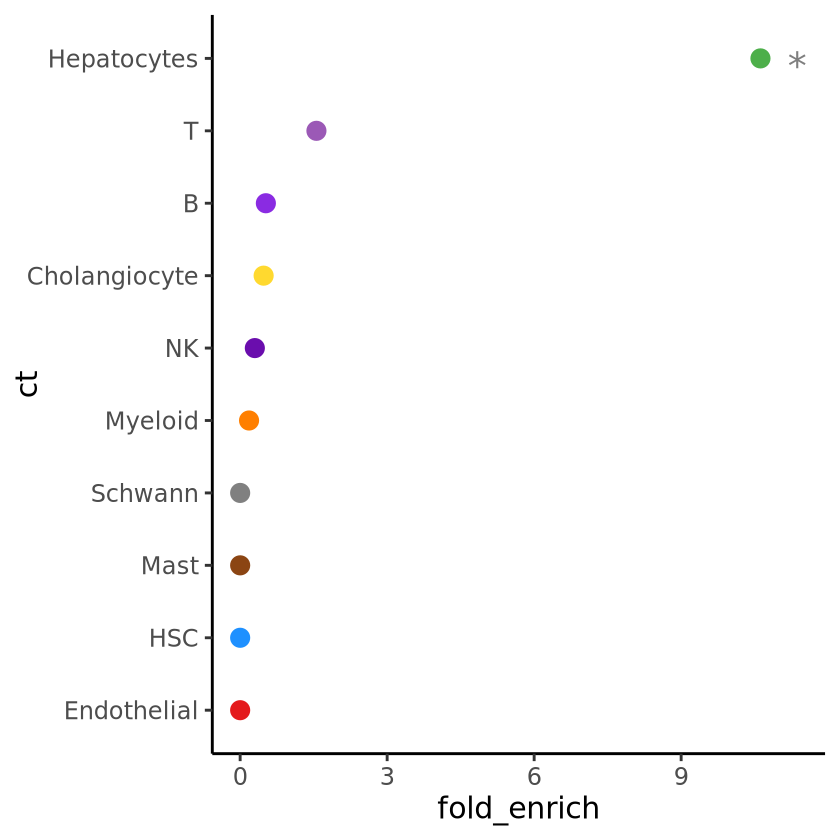

In [250]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_celltype_markers_dotplot.pdf')

filter(new.marker.df, test.group=='Celltype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=celltype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=0.75)  +
            theme(legend.position='none')

#dev.off()

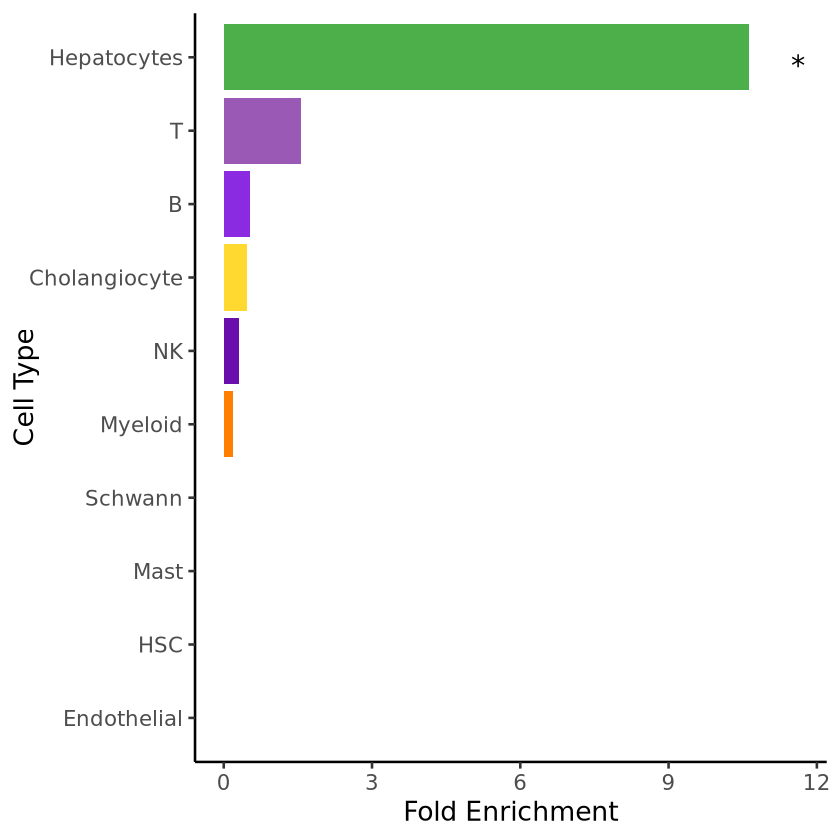

In [261]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_celltype_specific_barplot.pdf')

filter(new.marker.df, test.group=='Celltype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=celltype_colors) + theme(legend.position='None')

#dev.off()

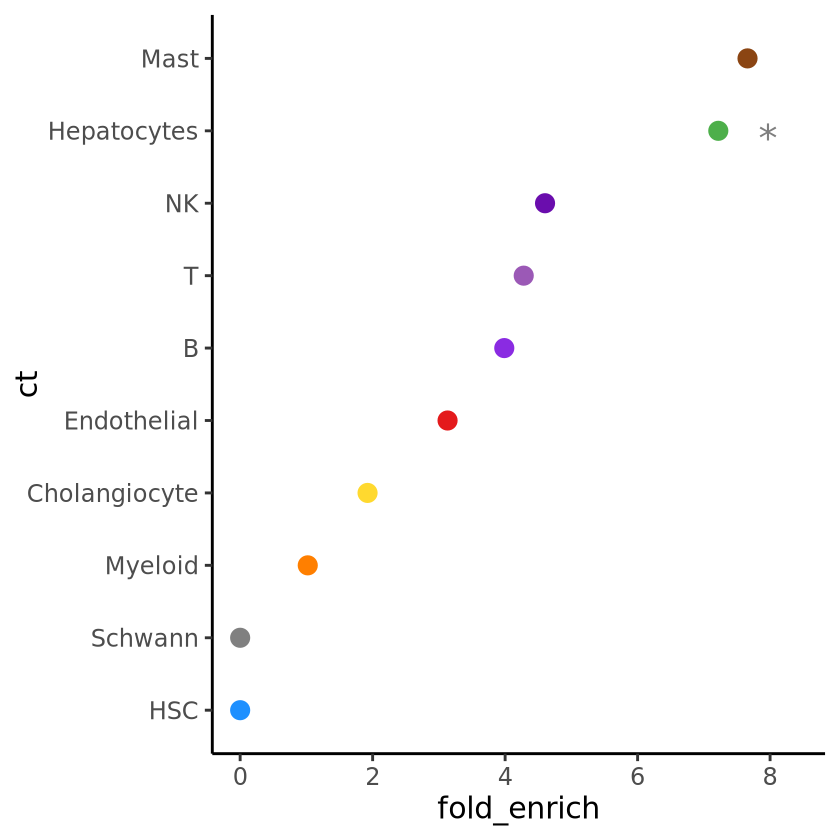

In [263]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_celltype_marker_dotplot.pdf')

filter(new.marker.df, test.group=='Celltype.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=celltype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=0.75)  +
            theme(legend.position='none')

#dev.off()

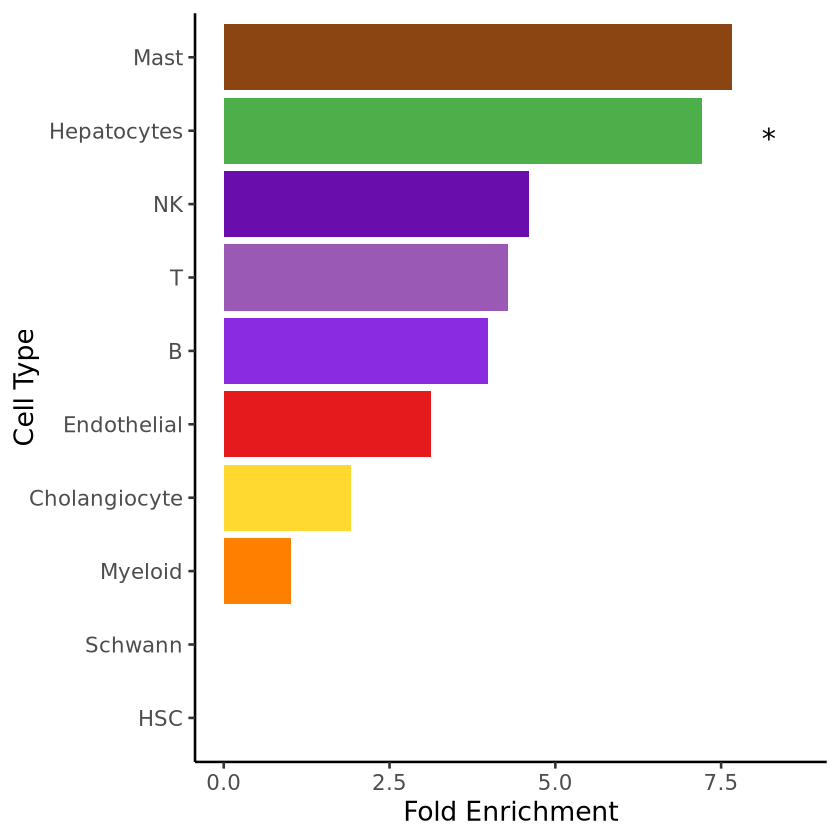

In [265]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_celltype_marker_barplot.pdf')

filter(new.marker.df, test.group=='Celltype.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=celltype_colors) + theme(legend.position='None')

#dev.off()

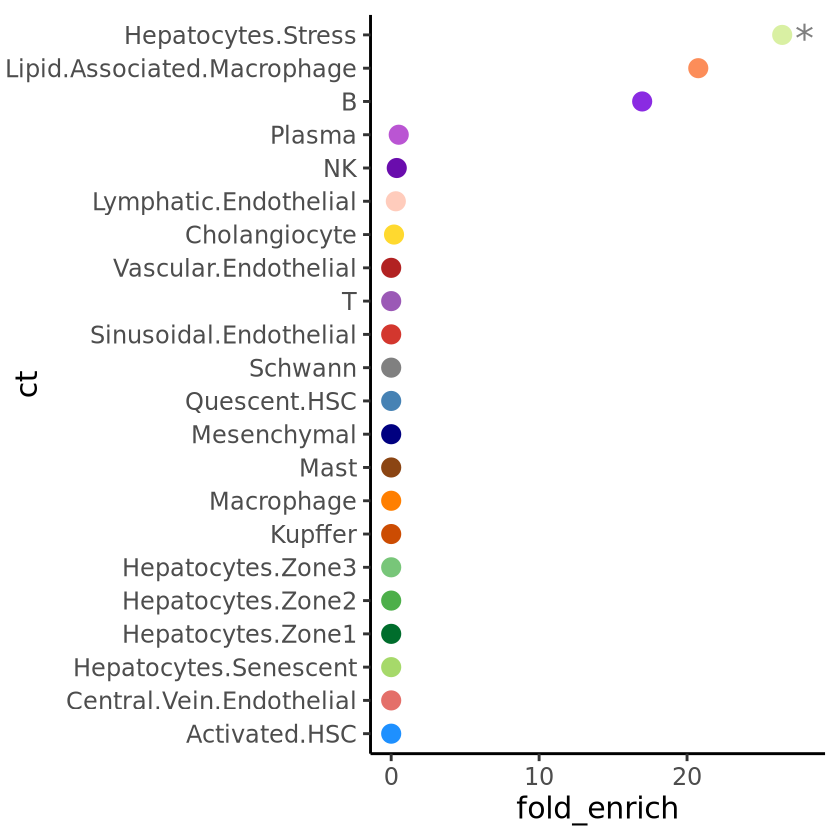

In [274]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_subtype_specific_dotplot.pdf')

filter(new.marker.df, test.group=='Subtype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

#dev.off()

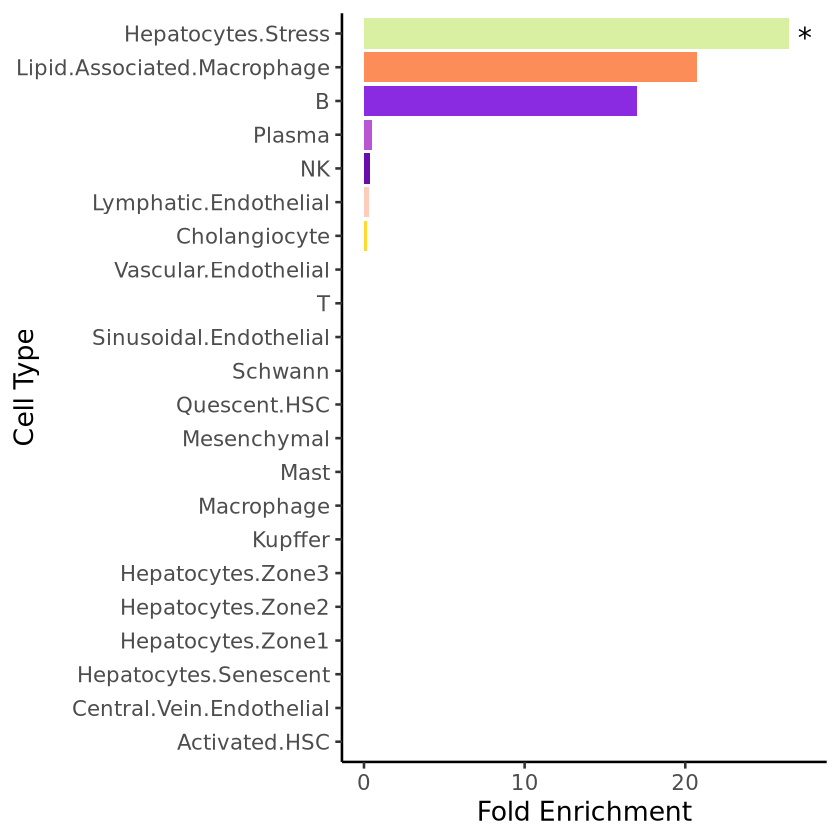

In [276]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_subtype_specific_barplot.pdf')

filter(new.marker.df, test.group=='Subtype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=cellsubtype_colors) + theme(legend.position='None')

#dev.off()

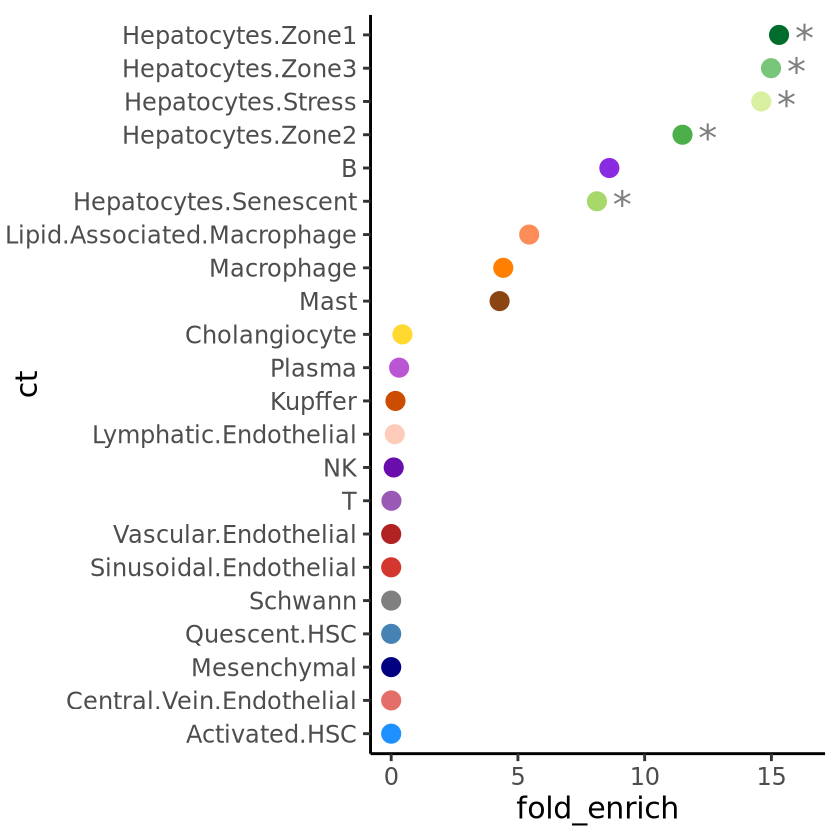

In [278]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_subtype_marker_dotplot.pdf')

filter(new.marker.df, test.group=='Subtype.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1)  +
            theme(legend.position='none')

#dev.off()

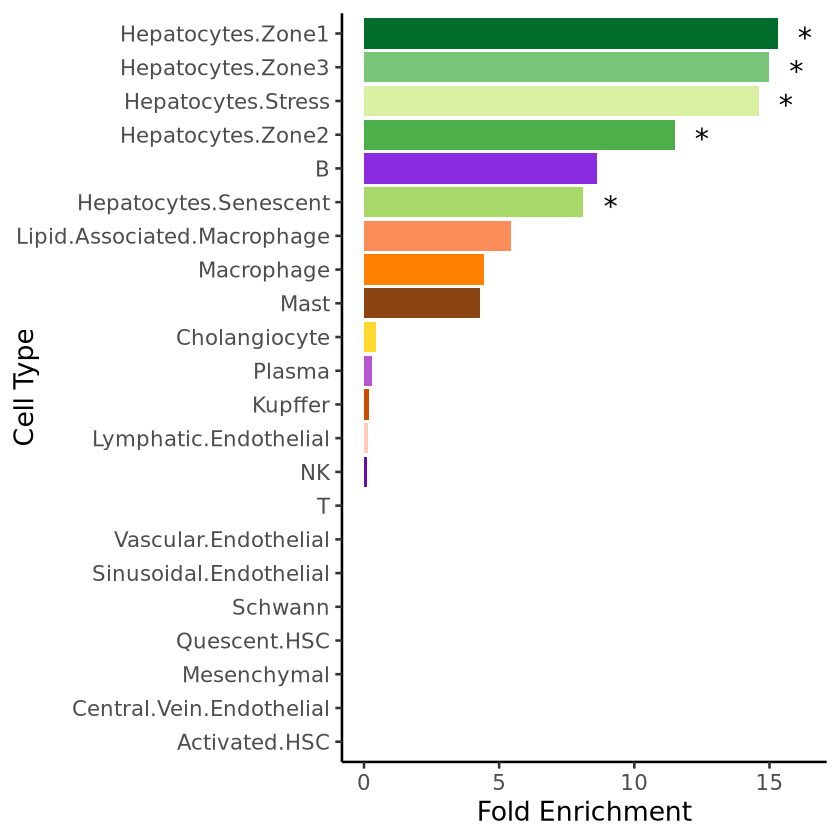

In [280]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_Yang_subtype_marker_barplot.pdf')

filter(new.marker.df, test.group=='Subtype.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=cellsubtype_colors) + theme(legend.position='None')

#dev.off()

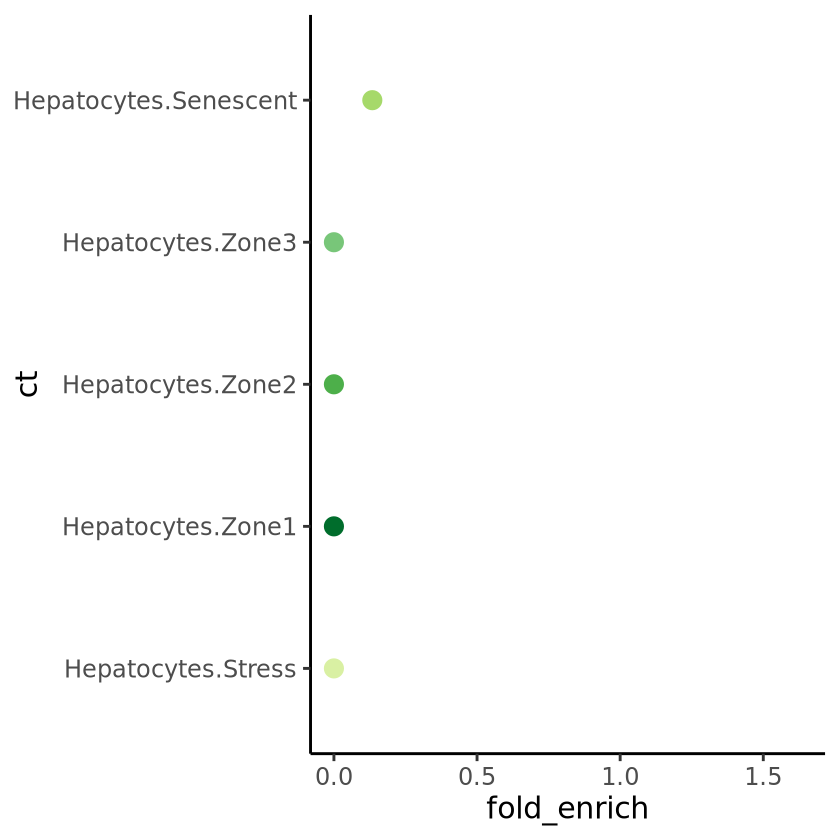

In [195]:
#filter(new.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(new.marker.df, test.group=='Hepatocytes.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_text()`).”


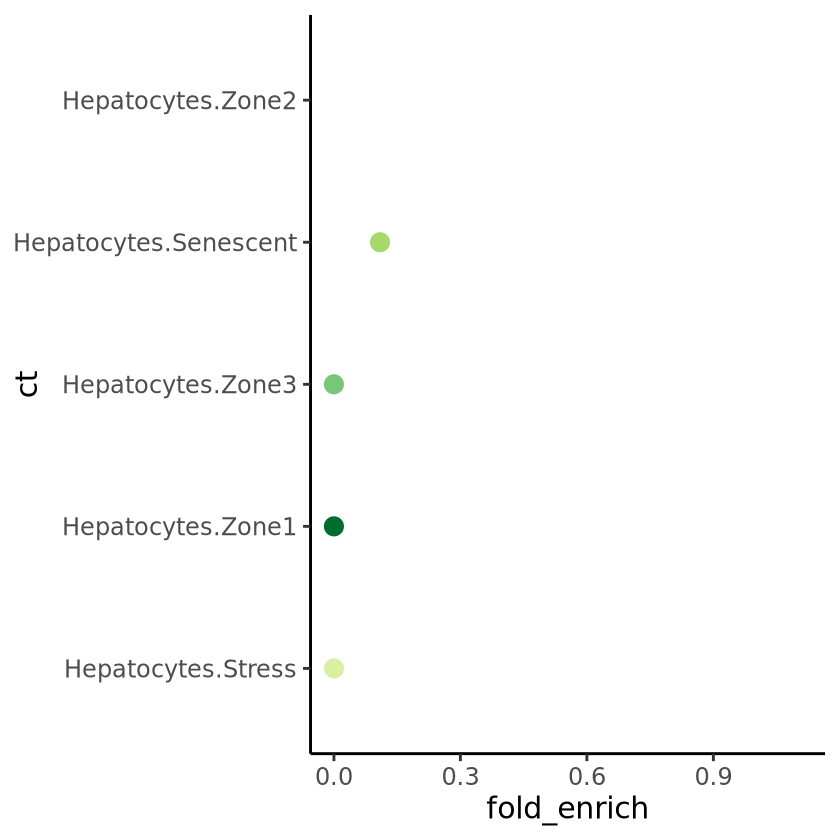

In [196]:
#filter(new.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(new.marker.df, test.group=='Hepatocytes.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1)  +
            theme(legend.position='none')

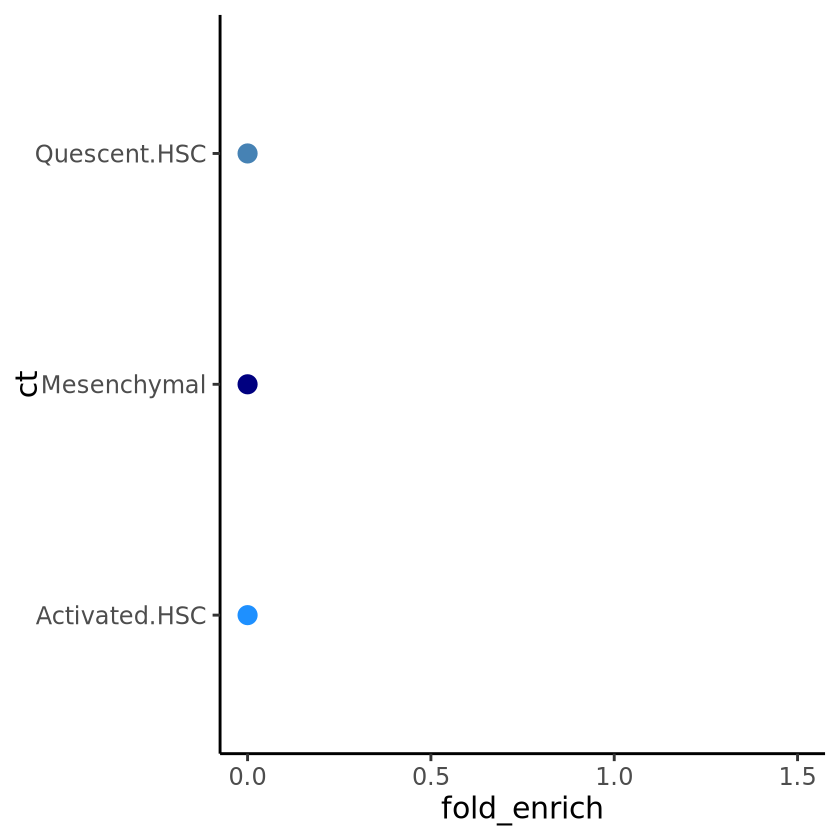

In [197]:
#filter(new.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(new.marker.df, test.group=='HSC.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

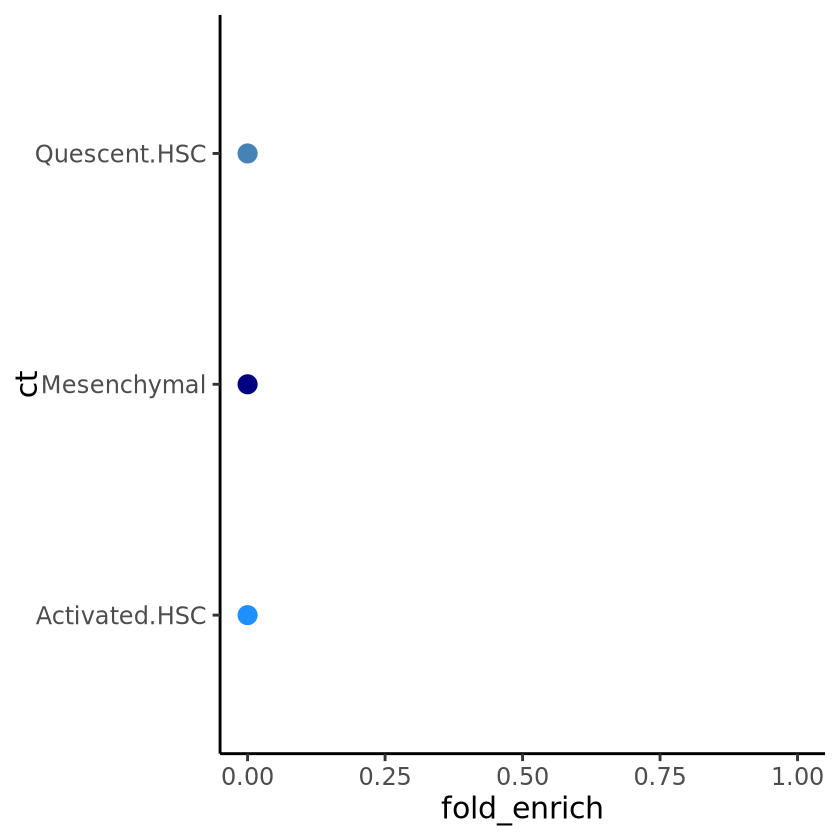

In [198]:
#filter(new.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(new.marker.df, test.group=='HSC.marker') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1)  +
            theme(legend.position='none')

In [170]:
old.marker.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,HSC.specific,NA,ATAC,NA,NA,Activated.HSC,HSC.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Activated.HSC,Subtype.specific,NA,ATAC,NA,NA,Activated.HSC,Subtype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.specific,NA,ATAC,NA,NA,B,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Subtype.specific,NA,ATAC,NA,NA,B,Subtype.specific,0.661,0.022990929681845174,-3.780019157389389,-5.788246792615643,11.135512654594622
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Celltype.specific,NA,ATAC,NA,NA,Central.Vein.Endothelial,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Subtype.specific,NA,ATAC,NA,NA,Central.Vein.Endothelial,Subtype.specific,0.572,0.01964257447135477,-3.935119489578739,-6.119746214082601,19.644056113662923
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,Celltype.specific,NA,ATAC,NA,NA,Cholangiocyte,Celltype.specific,0.5,0.15174669517965078,-1.8922841851860137,-3.9087825636553113,13.211786436615007
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,Subtype.specific,NA,ATAC,NA,NA,Cholangiocyte,Subtype.specific,0.469,0.13958122144037352,-1.9750021539178046,-4.030719644217636,14.799226999019385
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,Celltype.specific,NA,ATAC,NA,NA,Endothelial,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity


In [172]:
filter(old.marker.df, test.group=='Celltype.specific')

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,Celltype.specific,NA,ATAC,NA,NA,B,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Central.Vein.Endothelial,Celltype.specific,NA,ATAC,NA,NA,Central.Vein.Endothelial,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,Celltype.specific,NA,ATAC,NA,NA,Cholangiocyte,Celltype.specific,0.5,0.15174669517965078,-1.8922841851860137,-3.9087825636553113,13.211786436615007
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,Celltype.specific,NA,ATAC,NA,NA,Endothelial,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Kupffer,Celltype.specific,NA,ATAC,NA,NA,Kupffer,Celltype.specific,0.397,0.31096995090885826,-1.1844187673276636,-3.3055609342732013,13.811251218681925
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Lipid.Associated.Macrophage,Celltype.specific,NA,ATAC,NA,NA,Lipid.Associated.Macrophage,Celltype.specific,0.042,8.614496081552417,2.339088948186289,0.1753330365728669,19.065816027913886
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Lymphatic.Endothelial,Celltype.specific,NA,ATAC,NA,NA,Lymphatic.Endothelial,Celltype.specific,0.529,0.14248903907538327,-1.9711501753675502,-3.9888578612883654,9.899658138314194
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Macrophage,Celltype.specific,NA,ATAC,NA,NA,Macrophage,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Mast,Celltype.specific,NA,ATAC,NA,NA,Mast,Celltype.specific,1.0,0.0,-Infinity,-Infinity,-Infinity


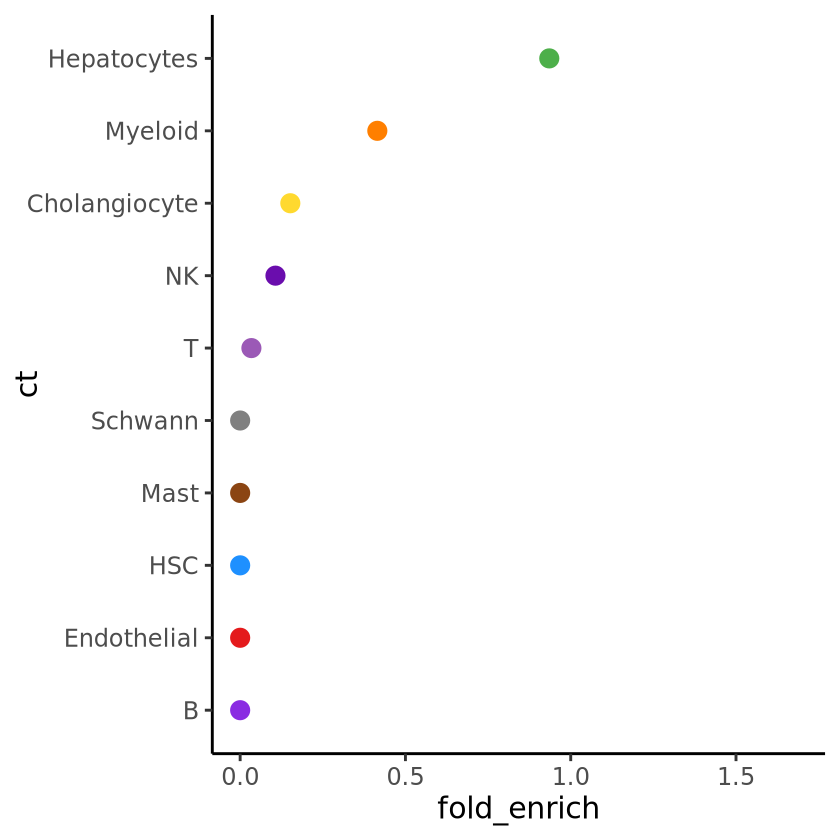

In [188]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='Celltype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=celltype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=0.75)  +
            theme(legend.position='none')

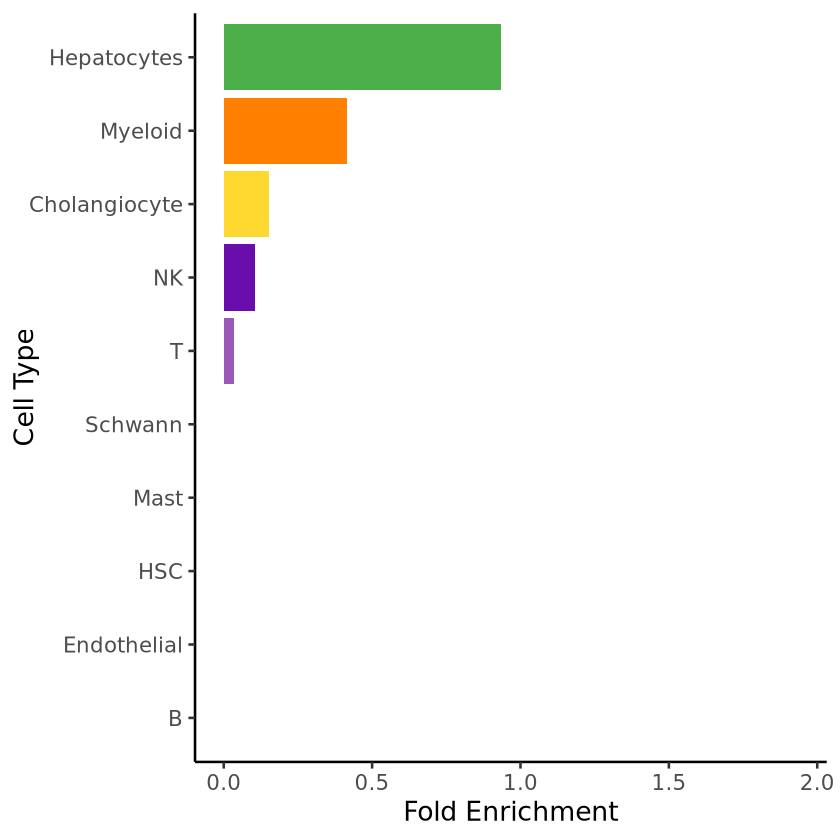

In [224]:
filter(old.marker.df, test.group=='Celltype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
             ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=celltype_colors) + theme(legend.position='None')

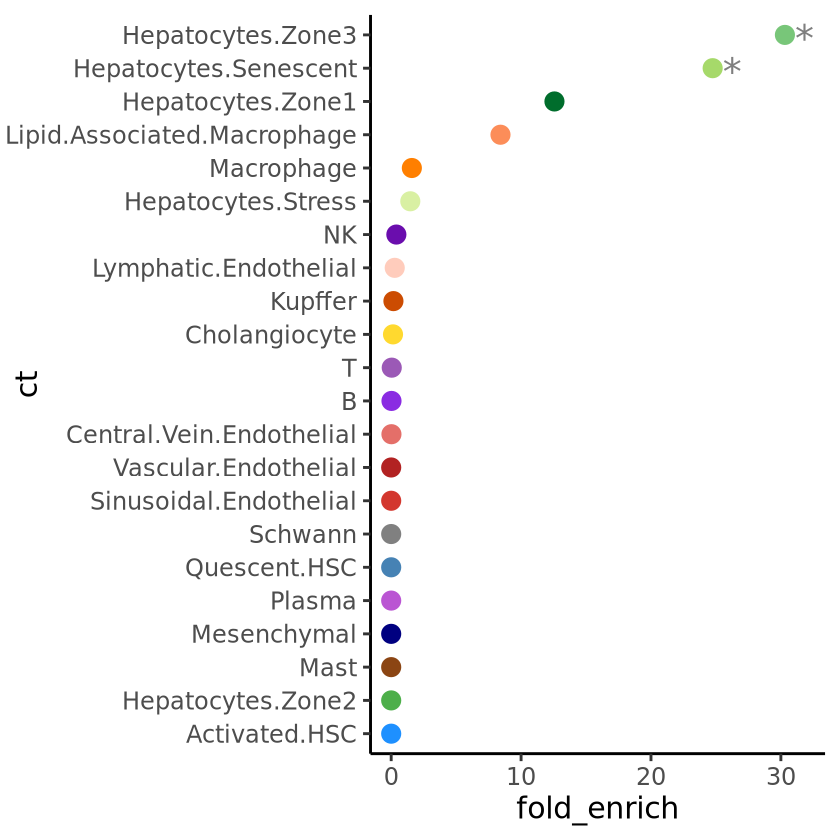

In [168]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='Subtype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

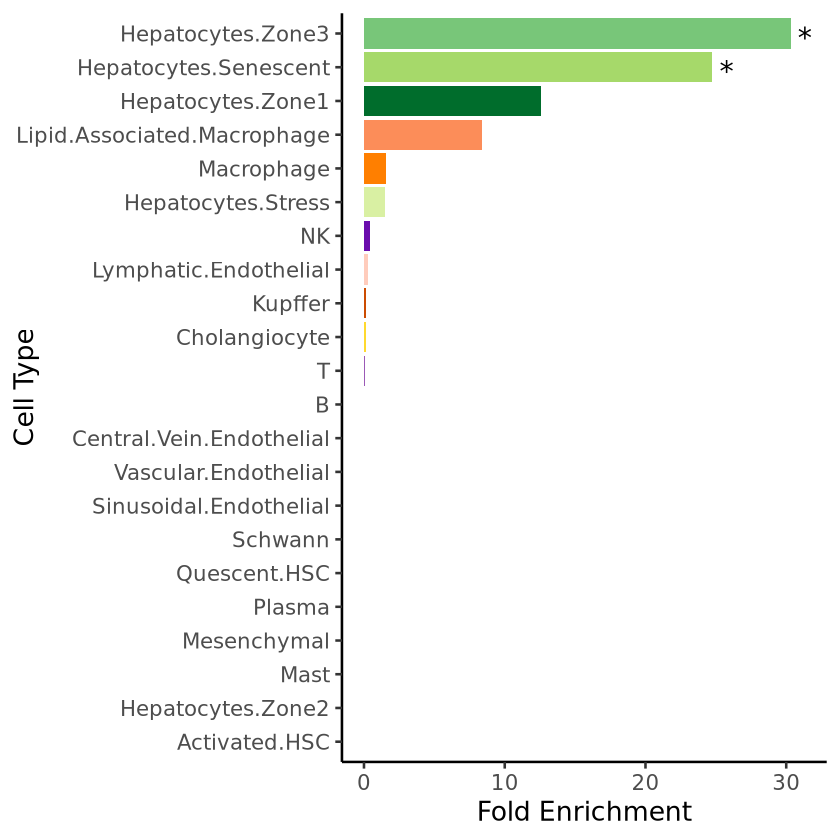

In [219]:
filter(old.marker.df, test.group=='Subtype.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=ct, fill=ct)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 1, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=cellsubtype_colors) + theme(legend.position='None')

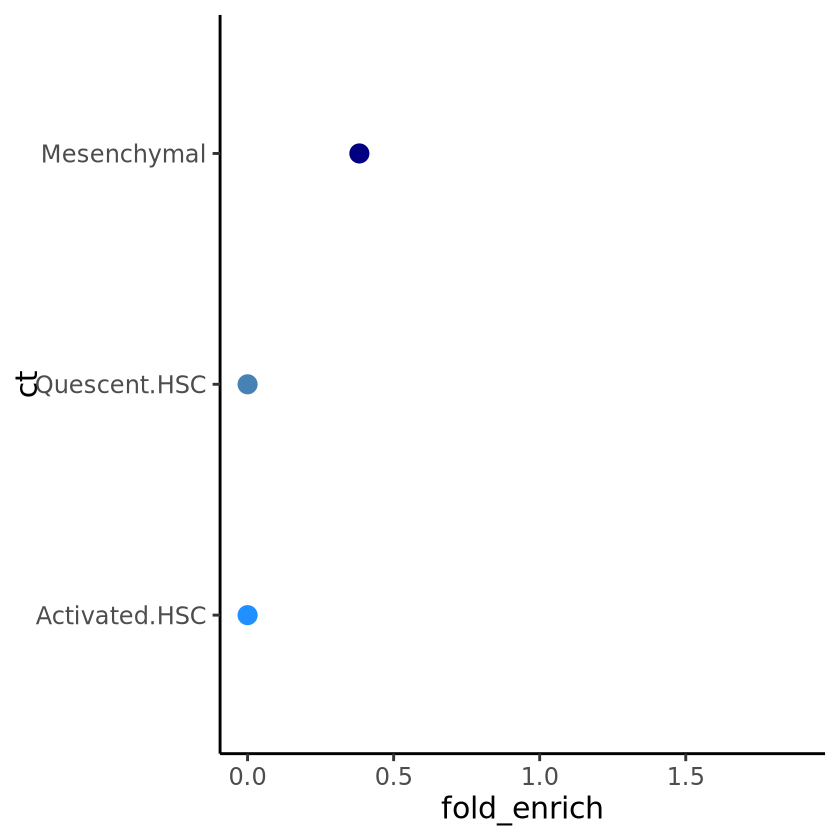

In [189]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='HSC.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

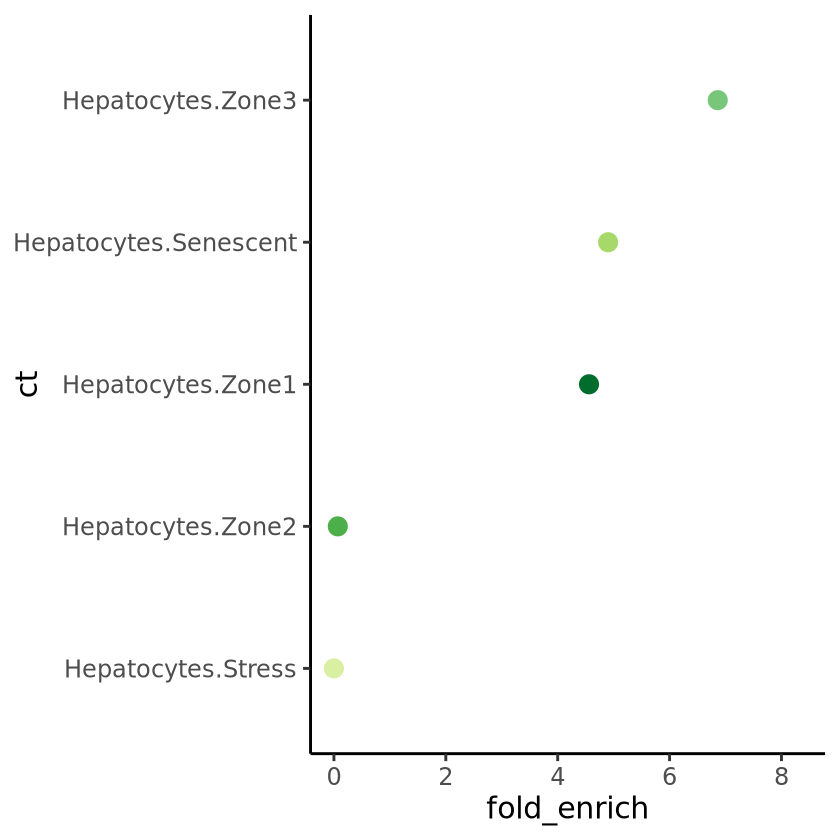

In [191]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='Hepatocytes.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

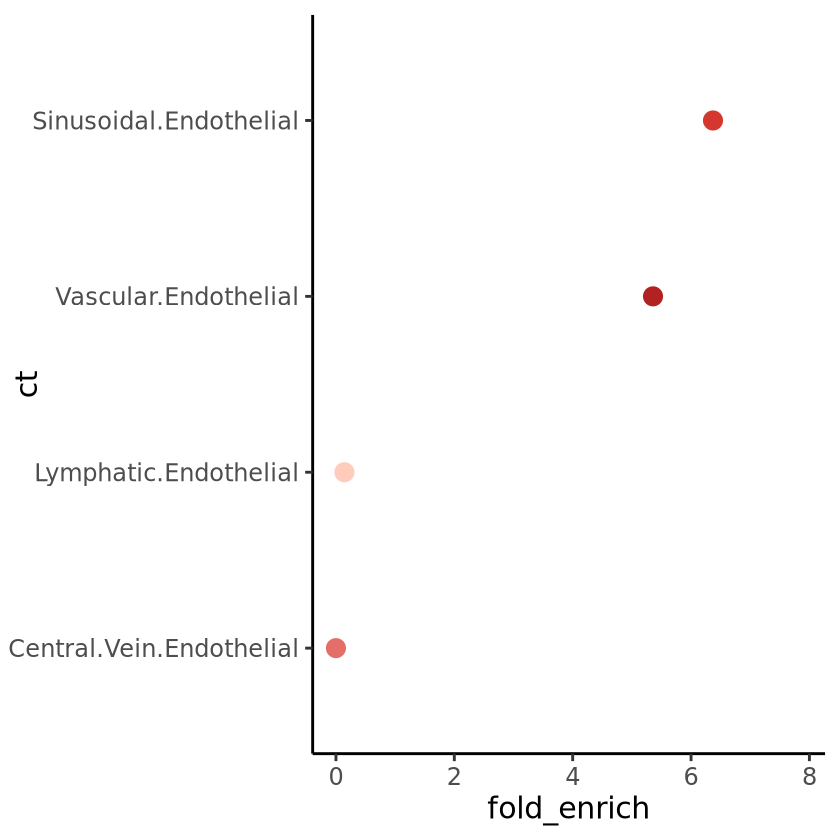

In [193]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='Endothelial.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

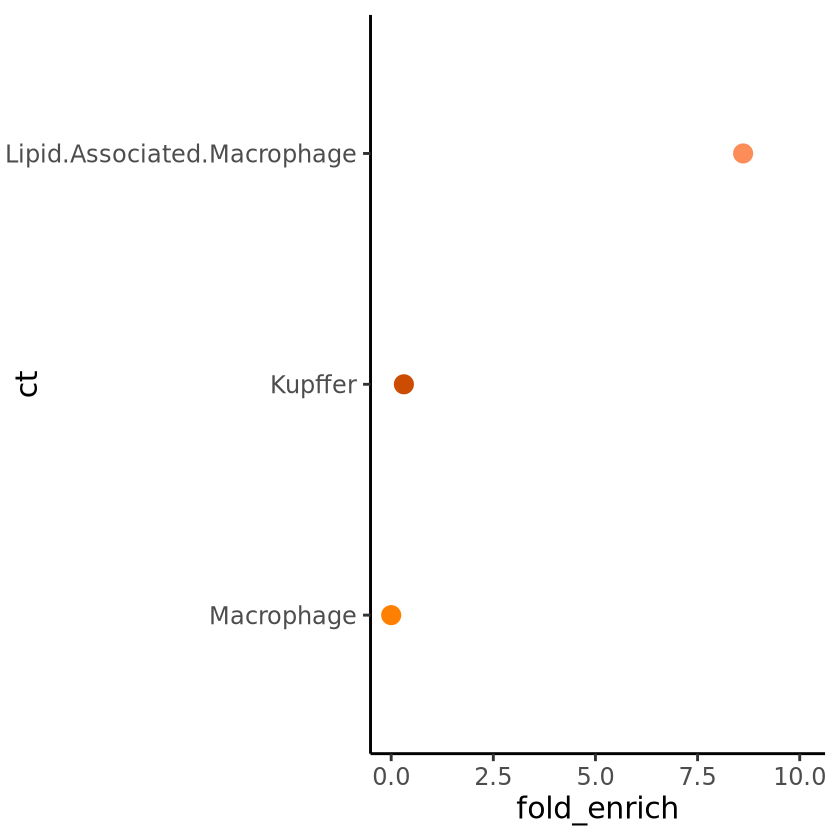

In [194]:
#filter(old.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(old.marker.df, test.group=='Myeloid.specific') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=cellsubtype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=1.5) +
            theme(legend.position='none')

In [344]:
files[grep('dds', files)]

[1] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_clusters.bed.results"         
 [2] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_on_clusters.bed.results"      
 [3] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASH_specific_clusters.bed.results"
 [4] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_clusters.bed.results"         
 [5] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_on_clusters.bed.results"      
 [6] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MASL_specific_cluste.results"      
 [7] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_differential_MetALD_clusters.bed.results"       
 [8] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_clusters.bed.results"                      
 [9] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_on_clusters.bed.results"                   
[10] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASH_specific_cluste.results"                   
[11] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_clusters.bed.results"                      
[12] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_on_clusters.bed.results"                   
[13] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MASL_specific_cluste.results"                   
[14] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Endothelial_disease_MetALD_clusters.bed.results"                    
[15] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_clusters.bed.results"         
[16] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_on_clusters.bed.results"      
[17] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASH_specific_cluste.results"      
[18] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_clusters.bed.results"         
[19] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_on_clusters.bed.results"      
[20] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MASL_specific_cluste.results"      
[21] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_differential_MetALD_clusters.bed.results"       
[22] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_clusters.bed.results"                      
[23] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_on_clusters.bed.results"                   
[24] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASH_specific_cluste.results"                   
[25] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_clusters.bed.results"                      
[26] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_on_clusters.bed.results"                   
[27] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MASL_specific_cluste.results"                   
[28] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_Hepatocytes_disease_MetALD_clusters.bed.results"                    
[29] "HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_WE_HSC_disease_differential_MASH_clusters.bed.results"                         
[30] "HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241217_W

In [212]:
filter(de.df, modality=='ATAC' & disease_condition=='Fibrosis.stage' & Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr'))

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,padj,B,DESeq,1.000,0.00000000,-Infinity,-Infinity,Infinity,1.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,up,padj,B,DESeq,1.000,0.00000000,-Infinity,-Infinity,Infinity,1.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,ATAC,down,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Infinity,-Infinity,-Infinity,1.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,ATAC,up,padj,Cholangiocyte,DESeq,0.249,1.43492488,0.4124878248751489,-0.9185903375632403,2.8585247193396657,0.7968
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,DESeq,Fibrosis.stage,ATAC,down,padj,Endothelial,DESeq,0.096,3.90233731,1.4538263516569898,-0.5542014089414447,12.635223074821102,0.5120
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,DESeq,Fibrosis.stage,ATAC,up,padj,Endothelial,DESeq,0.573,0.77226321,-0.29939989808112244,-1.7134342898910924,1.9422788223554341,1.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,DESeq,Fibrosis.stage,ATAC,down,padj,Hepatocytes,DESeq,0.000,5.17657943,1.9072216743682375,0.5332742620477945,5.123448779865226,0.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,DESeq,Fibrosis.stage,ATAC,up,padj,Hepatocytes,DESeq,0.984,0.08276458,-2.5870940027878326,-3.792873367199589,-0.49073115420540003,1.0000
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,DESeq,Fibrosis.stage,ATAC,down,padj,HSC,DESeq,0.047,3.46508223,1.364492071991868,-0.34749954217439316,7.195391881625756,0.3760


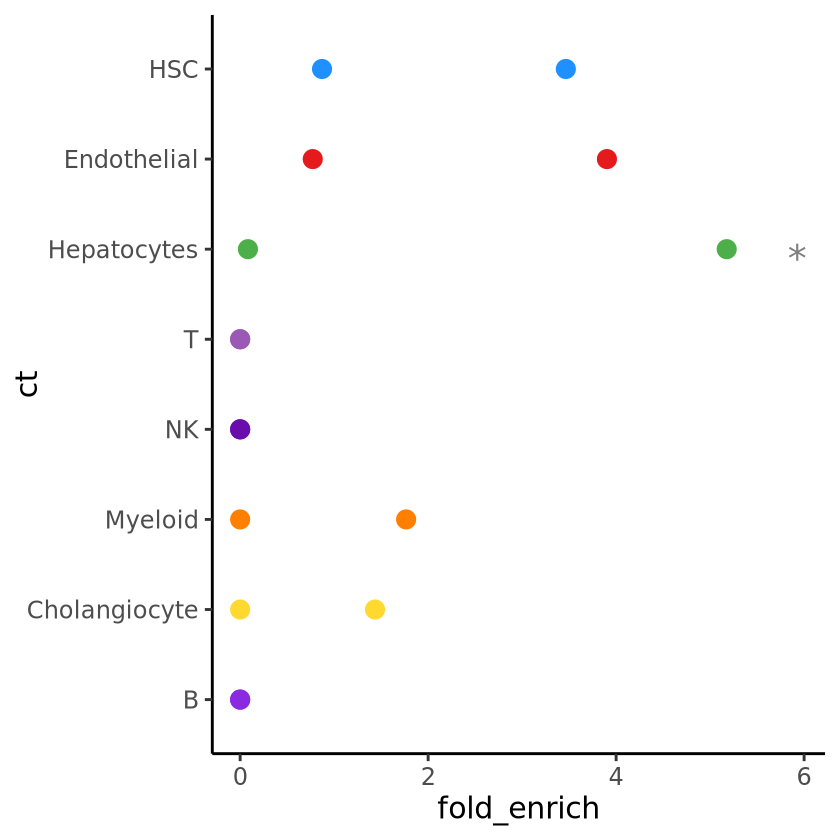

In [213]:
#filter(new.marker.df, test.group=='Celltype.marker') %>%
#                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
#                mutate(padj=p.adjust(pval, method='fdr')) %>%
#                arrange(fold_enrich) %>%
#                mutate(ct=factor(ct, levels=ct))

filter(de.df, modality=='ATAC' & disease_condition=='Fibrosis.stage' & Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(x=fold_enrich, y=ct, color=ct, group=DESeq_direction)) + 
            geom_point(size=5) + 
            theme_classic(base_size=18) +
            scale_color_manual(values=celltype_colors) +
            geom_text(aes(label = lab, color='black'), size=8, nudge_y = -.1, nudge_x=0.75)  +
            theme(legend.position='none')

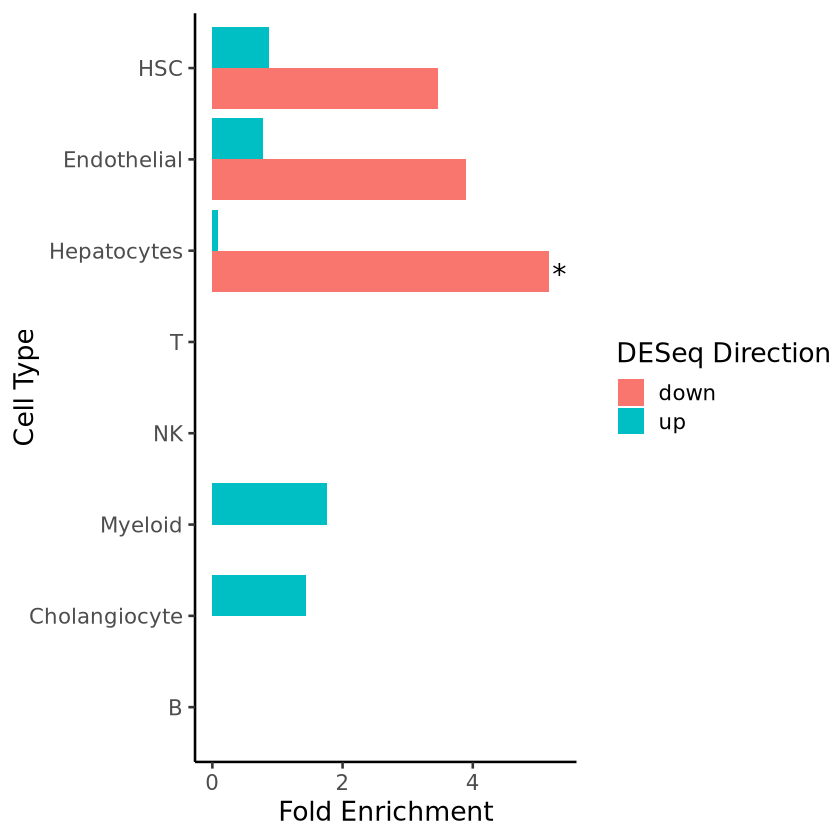

In [282]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.df, modality=='ATAC' & disease_condition=='Fibrosis.stage' & Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = 0.15, nudge_x=-.25) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction')

#dev.off()

In [ ]:
ggplot(MVP.Fibrosis.ATAC, aes(y=fold_enrich, x=cell_type, fill=DESeq_direction)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = label), size=6, nudge_y = 0.15, nudge_x=-.25) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction')